In [320]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as mtransforms
import matplotlib.gridspec as gridspec
from scipy.interpolate import Akima1DInterpolator

root_path = 'C:/GIT_REPOS/SCT/COSY/src/dat/'
src_path = 'C:/GIT_REPOS/SCT/COSY/src/'

In [321]:
class Particle:
    c_light = 299792458.0

    def __init__(self, T_MeV, mass_MeV, charge_units):
        self.T = T_MeV
        self.m0 = mass_MeV
        self.q = charge_units
        
        # Relativistic params
        self.E_tot = self.T + self.m0
        self.gamma = self.E_tot / self.m0
        self.beta = np.sqrt(1 - 1/self.gamma**2)
        self.p_MeVc = np.sqrt(self.E_tot**2 - self.m0**2)
        
        # Rigidities
        # Magnetic [T*m]
        self.B_rho = (self.p_MeVc * 1e6) / (self.c_light * abs(self.q))
        # Electric [V]
        self.E_rho = (self.p_MeVc * 1e6 * self.beta) / abs(self.q)

class Proton(Particle):
    def __init__(self, T_MeV): super().__init__(T_MeV, 938.272, 1)

class Deuteron(Particle):
    def __init__(self, T_MeV): super().__init__(T_MeV, 1875.613, 1)

In [322]:
class EntityBase:
    SCHEMAS = {}

    def __init__(self, cmd, params, name):
        self.name = name
        self.type = cmd
        self.entity = self.__class__.__name__
        
        # 1. Initialize all possible fields to None
        all_fields = set()
        for s in self.SCHEMAS.values(): all_fields.update(s.keys())
        for f in all_fields: setattr(self, f, None)
        
        # Default Length
        self.L = 0.0

        # 2. Parse Params
        layout = self.SCHEMAS.get(cmd, {})
        for attr, idx in layout.items():
            if idx < len(params):
                setattr(self, attr, float(params[idx]))
        
        # 3. Initial Geometric Calculation (Static)
        self._calculate_derived()

    def _calculate_derived(self):
        """Static geometry updates (e.g., L from Radius/Angle)"""
        pass

    def update_from_particle(self, particle):
        """
        Dynamic physics updates.
        Calculates angle/radius based on particle rigidity.
        Overridden by subclasses.
        """
        pass
    
    def __repr__(self): return f"<{self.entity}: {self.name}>"

In [323]:
class Quadrupole(EntityBase):
    SCHEMAS = {
        'QUAD': {'L': 0, 'tilt': 1, 'k1': 2},
        'MQ':   {'L': 0, 'b_tip': 1, 'aperture': 2}
    }
    
class Dipole(EntityBase):
    SCHEMAS = {
        'SBEND': {'L': 0, 'angle': 1, 'tilt': 2, 
                  'e1': 3, 'h1': 4, 'e2': 5, 'h2': 6},
        'DI':    {'radius': 0, 'angle': 1, 'aperture': 2, 
                  'e1': 3, 'h1': 4, 'e2': 5, 'h2': 6}
    }

    def _calculate_derived_params(self):
        # Связь L = R * Angle
        if self.L and self.angle and self.radius is None:
            self.radius = self.L / abs(self.angle) if self.angle != 0 else 0.0
        elif self.radius is not None and self.angle and (self.L is None or self.L == 0):
            self.L = abs(self.radius * self.angle)

class Sextupole(EntityBase):
    SCHEMAS = {
        'SEXT': {'L': 0, 'tilt': 1, 'strength': 2}, # KNL
        'MH':   {'L': 0, 'strength': 1, 'aperture': 2} # Bpt
    }

class ElectrostaticQuadrupole(EntityBase):
    SCHEMAS = {
        'EQ': {'L': 0, 'voltage': 1, 'aperture': 2}
    }

class ElectrostaticDeflector(EntityBase):
    SCHEMAS = {
        'ED':  {'L': 0, 'E_kVcm': 1, 'tilt': 2},
        'ECL': {'radius': 0, 'angle_deg': 1, 'aperture': 2}
    }

    def _calculate_derived(self):
        # Convert Angle(deg) -> Rads if Angle is given explicitly (ECL)
        if getattr(self, 'angle_deg', None) is not None:
            self.angle = self.angle_deg * np.pi / 180.0
            if self.radius is not None and (self.L is None or self.L == 0):
                self.L = abs(self.radius * self.angle)
        
        # Initialize angle to 0 if not set (ED case)
        if not hasattr(self, 'angle') or self.angle is None:
            self.angle = 0.0

    def update_from_particle(self, particle):
        """
        Implements the COSY ED logic:
        ANGDEF := L / (E_rho / E_field)
        """
        # If angle is already set (ECL), do not overwrite
        if abs(self.angle) > 1e-9: return

        # Check for Field (ED)
        e_kv = getattr(self, 'E_kVcm', 0.0)
        if e_kv is not None and abs(e_kv) > 1e-9:
            # 1. Convert to SI [V/m]
            E_field_Vm = e_kv * 1e5 
            
            # 2. Calculate Radius [m] = Erho / E
            # Note: Sign convention. Assuming E>0 bends Left.
            self.radius = particle.E_rho / E_field_Vm
            
            # 3. Calculate Angle [rad] = L / R
            self.angle = self.L / self.radius

class WienFilter(EntityBase):
    SCHEMAS = {
        'WIEN': {'L': 0, 'B_kGs': 1, 'E_kVcm': 2, 'tilt': 3},
        'WF':   {'Re': 0, 'Rm': 1, 'L': 2, 'aperture': 3}
    }

class Drift(EntityBase):
    SCHEMAS = {'DL': {'L': 0}}

ENTITY_FACTORY = {
    'QUAD': Quadrupole, 'MQ': Quadrupole,
    'SBEND': Dipole, 'DI': Dipole,
    'ED': ElectrostaticDeflector, 'ECL': ElectrostaticDeflector,
    'EQ': ElectrostaticQuadrupole,
    'WIEN': WienFilter, 'WF': WienFilter,
    'DL': Drift,
    'MH': Sextupole, 'SEXT': Sextupole
}

In [324]:
class LatticeSlot:
    def __init__(self, type_key, element_id, s_start, library):
        self.type_key = type_key
        self.id = element_id
        self.s = s_start
        self.phys = library[type_key] # Ссылка на физический объект
        self.betx = 0.0; self.bety = 0.0; self.dispx = 0.0; self.dispy = 0.0

In [325]:
class FoxParser:
    def __init__(self, filepath, global_vars=None):
        self.filepath = filepath
        self.vars = global_vars.copy() if global_vars else {}
        self.library = {} 
        self.sequence = [] 
        
        with open(filepath, 'r', encoding='utf-8') as f:
            self.raw_content = f.read()
            
    def parse(self):
        self._extract_variables() # Шаг 1: Считаем математику
        self._build_structure()   # Шаг 2: Строим решетку
        return self.library, self.sequence

    def _extract_variables(self):
        # Ищем все присваивания VAR := VAL;
        assigns = re.findall(r'(\w+)\s*:=\s*([^;]+);', self.raw_content)
        
        for name, expr in assigns:
            # ВАЖНО: Сортируем ключи от длинных к коротким, чтобы Ld заменилось раньше L
            sorted_keys = sorted(self.vars.keys(), key=len, reverse=True)
            
            for k in sorted_keys:
                if k in expr: expr = expr.replace(k, str(self.vars[k]))
            
            try:
                clean = expr.replace('ABS', 'abs').replace('1E', '1e').replace('{', '').replace('}', '')
                val = float(eval(clean, {"__builtins__": None, "abs": abs}))
                self.vars[name.strip()] = val
            except: pass

    def _build_structure(self):
        known_cmds = list(ENTITY_FACTORY.keys())
        pattern = r'\b(' + '|'.join(known_cmds) + r')\b\s+([^;{]+)\s*;\s*(?:\{([^}]+)\})?'
        matches = re.findall(pattern, self.raw_content, re.IGNORECASE)
        
        current_s, element_id = 0.0, 1
        
        for cmd, params_raw, comment in matches:
            cmd = cmd.upper()
            
            # 1. Вычисляем параметры для КОНКРЕТНОГО элемента (2*0.5, Lds...)
            p_num = self._evaluate_params(params_raw)
            
            # 2. Создаем ключ библиотеки (Имя + Параметры)
            name = comment.strip() if (comment and comment.strip()) else cmd
            lib_key = f"{name}_{tuple(p_num)}"
            
            # 3. Создаем объект в библиотеке, если его нет
            if lib_key not in self.library:
                try:
                    self.library[lib_key] = ENTITY_FACTORY[cmd](cmd, p_num, name)
                except Exception as e:
                    print(f"⚠️ Ошибка создания {name}: {e}")
                    continue

            # 4. Создаем слот
            slot = LatticeSlot(lib_key, element_id, current_s, self.library)
            self.sequence.append(slot)
            current_s += slot.phys.L
            element_id += 1

    def _evaluate_params(self, params_str):
        raw_list = params_str.strip().split()
        result = []
        
        # ВАЖНО: Также сортируем здесь перед подстановкой в параметры (для 2*0.5 Ld)
        sorted_keys = sorted(self.vars.keys(), key=len, reverse=True)

        for item in raw_list:
            expr = item
            for k in sorted_keys:
                if k in expr: expr = expr.replace(k, str(self.vars[k]))
            try: 
                result.append(float(eval(expr, {"__builtins__": None})))
            except: 
                result.append(0.0)
        return result

In [326]:
def load_optics(lattice_sequence, dat_path, lattice_name):
    folder = lattice_name.replace('_maps', '')
    full_path = os.path.join(dat_path, folder)
    print(f"📂 Данные из: {full_path}")
    
    files = {'BETAX': 'betx', 'BETAY': 'bety', 'DISPX': 'dispx'}
    for fname, attr in files.items():
        p = os.path.join(full_path, fname)
        if os.path.exists(p):
            try:
                # ИСПРАВЛЕНО: sep=r'\s+' (добавлена r перед строкой)
                df = pd.read_csv(p, sep=r'\s+', header=None, skiprows=1)
                
                vals = df.iloc[:, 0].values
                for i, slot in enumerate(lattice_sequence):
                    if i < len(vals): setattr(slot, attr, vals[i])
                print(f"   ✅ {fname} загружен")
            except Exception as e: print(f"   ❌ Ошибка чтения {fname}: {e}")
        else: print(f"   ⚠️ Нет файла {fname}")

In [364]:
# --- КОНФИГУРАЦИЯ ---
#lattice_name = 'magnetic_2p_maps'
lattice_name = 'electrostatic_maps'
root_dat = 'C:/GIT_REPOS/SCT/COSY/src/dat/'
src_file = f'C:/GIT_REPOS/SCT/COSY/src/{lattice_name}.fox'

# 1. Входные данные для PROCEDURE LATTICE
global_inputs = {
    'EB1': 112.464392, 
    'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
    'SEXTGy1': -0.1, 'SEXTGy2': -0.1,
    'RFFLAG': 0, 'MAPARR': 0, 'SPNRARR': 0,
    'A': 0.05
}

# 2. ИНИЦИАЛИЗАЦИЯ ПАРСЕРА
parser = FoxParser(src_file, global_inputs)

# 3. ПАРСИНГ (Автоматически считает переменные и строит решетку)
library, sequence = parser.parse()

# 4. ЗАГРУЗКА ДАННЫХ
load_optics(sequence, root_dat, lattice_name)

📂 Данные из: C:/GIT_REPOS/SCT/COSY/src/dat/electrostatic
   ✅ BETAX загружен
   ✅ BETAY загружен
   ✅ DISPX загружен


In [365]:
class FloorPainter:
    C = { 
        "Mag_Dipole": "#1f77b4",  # Классический Синий
        "Elec_Defl":  "#9467bd",  # Фиолетовый (Отличается, но гармонирует)
        "Q_Mag":      "#d62728",  # Красный
        "Q_Elec":     "#e377c2",  # Малиновый
        "Sext":       "#32CD32",  # Ярко-зеленый (Лайм)
        "Wien":       "#ff7f0e",  # Оранжевый
        "Drift":      "black" 
    }

    @classmethod
    def get_style(cls, el):
        # (Color, Width, Label)
        # Width увеличен для читаемости (было ~0.6 -> стало 2.0+)
        
        name = el.entity
        
        if "Dipole" in name:
            return cls.C["Mag_Dipole"], 2.2, "Magnetic Dipole"
            
        if "ElectrostaticDeflector" in name:
            return cls.C["Elec_Defl"], 2.2, "Electrostatic Deflector"
            
        if "Quadrupole" in name:
            if "Electrostatic" in name:
                return cls.C["Q_Elec"], 2.2, "Electrostatic Quad"
            else:
                return cls.C["Q_Mag"], 2.2, "Magnetic Quad"
                
        if "Sextupole" in name:
            return cls.C["Sext"], 2.2, "Sextupole"
            
        if "Wien" in name:
            return cls.C["Wien"], 2.2, "Wien Filter"
            
        return "grey", 0.5, None

    @classmethod
    def draw_element(cls, ax, item):
        el = item['slot'].phys
        if el.entity == "Drift": return None

        color, width, label_key = cls.get_style(el)

        # БЛОК
        rect = patches.Rectangle((-item['L']/2, -width/2), item['L'], width, 
                                 facecolor=color, edgecolor='black', 
                                 alpha=1.0, lw=0.8, zorder=10)
        
        t = mtransforms.Affine2D().rotate(item['theta']).translate(item['z'], item['x'])
        rect.set_transform(t + ax.transData)
        ax.add_patch(rect)
        
        return label_key

def plot_floor_plan(sequence, particle, n_periods=1, title="Ring Layout"):
    # Компактный размер 8x8
    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)
    
    data, (px, pz) = compute_survey(sequence, particle, n_periods)
    
    # Орбита (Тонкая)
    ax.plot(pz, px, 'k--', lw=0.8, alpha=0.4, label='Beam Orbit', zorder=1)
    
    # Легенда (Собираем используемые типы)
    legend_items = {} 
    
    for item in data:
        label_key = FloorPainter.draw_element(ax, item)
        if label_key:
            el = item['slot'].phys
            c, _, _ = FloorPainter.get_style(el)
            legend_items[label_key] = c

    # Оформление
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_xlabel('Z [m]', fontsize=11, fontweight='bold')
    ax.set_ylabel('X [m]', fontsize=11, fontweight='bold')
    
    info = f"{particle.__class__.__name__} ({particle.T} MeV)"
    if n_periods > 1: info += f" x {n_periods}"
    plt.title(f"{title}\n{info}", fontsize=12)
    
    ax.plot(0, 0, 'ko', markersize=4, zorder=20)

    # --- ГЕНЕРАЦИЯ ЛЕГЕНДЫ ---
    handles = [plt.Line2D([0], [0], color='k', lw=1, linestyle='--', label='Orbit')]
    
    for name in sorted(legend_items.keys()):
        color = legend_items[name]
        # Рисуем квадрат в легенде
        patch = patches.Patch(facecolor=color, edgecolor='black', label=name)
        handles.append(patch)
        
    ax.legend(handles=handles, loc='best', fontsize=9, framealpha=0.95)

    plt.tight_layout()
    plt.show()

In [366]:
class LatticeStyle:
    PALETTE = {
        "Dipole":                  "#1f77b4", # Blue
        "ElectrostaticDeflector":  "#00BFFF", # Cyan
        "Quadrupole":              "#d62728", # Red
        "ElectrostaticQuadrupole": "#e377c2", # Magenta
        "Sextupole":               "#2ca02c", # Green
        "ElectrostaticSextupole":  "#32CD32", # Lime
        "WienFilter":              "#ff7f0e", # Orange
        "Drift":                   "black"
    }

    @staticmethod
    def draw_header(fig, title, particle, extra_info=None):
        fig.subplots_adjust(top=0.88)
        fig.text(0.5, 0.96, title, ha='center', va='top', 
                 fontsize=18, fontweight='bold', color='#222', transform=fig.transFigure)
        sub = f"{particle.__class__.__name__} ({particle.T} MeV)"
        if extra_info: sub += f" | {extra_info}"
        fig.text(0.5, 0.925, sub, ha='center', va='top', 
                 fontsize=13, family='monospace', color='#555', transform=fig.transFigure)

    @staticmethod
    def get_visual_length(L):
        return max(L, 0.35)

    @classmethod
    def _get_base_props(cls, element):
        name = element.entity
        val = getattr(element, 'k1', getattr(element, 'b_tip', getattr(element, 'voltage', getattr(element, 'strength', 0)))) or 0
        focus = val >= 0 
        
        # Color lookup by substring
        color = "grey"
        for key in cls.PALETTE:
            if key in name:
                color = cls.PALETTE[key]
                break
        
        return name, color, focus

    @classmethod
    def get_floor_props(cls, element):
        """
        Стили для Floor Plan.
        UPD: Элементы сделаны значительно крупнее (w).
        """
        name, color, _ = cls._get_base_props(element)
        
        if "Dipole" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Magnetic Dipole"}
        elif "Deflector" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Electrostatic Deflector"}
            
        elif "Quadrupole" in name:
            lbl = "Electrostatic Quadrupole" if "Electrostatic" in name else "Magnetic Quadrupole"
            return {'c': color, 'w': 2.4, 'lbl': lbl}
            
        elif "Sextupole" in name:
            return {'c': color, 'w': 2.2, 'lbl': "Sextupole"}
            
        elif "Wien" in name:
            return {'c': color, 'w': 2.4, 'lbl': "Wien Filter"}
            
        return {'c': 'grey', 'w': 0.6, 'lbl': None}

    @classmethod
    def get_optics_props(cls, element):
        name, color, focus = cls._get_base_props(element)
        is_elec = "Electrostatic" in name
        
        if "Dipole" in name:      return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'B'}
        elif "Deflector" in name: return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'ED'}
        
        elif "Quadrupole" in name:
            prefix = "EQ" if is_elec else "Q"
            label = f"{prefix}F" if focus else f"{prefix}D"
            return {'c': color, 'h': 0.9, 'y': 0.0 if focus else -0.9, 'txt': label}
            
        elif "Sextupole" in name:
            label = "SF" if focus else "SD"
            return {'c': color, 'h': 0.7, 'y': 0.0 if focus else -0.7, 'txt': label}
            
        elif "Wien" in name:      return {'c': color, 'h': 0.7, 'y': -0.35, 'txt': 'WF'}
        
        return {'c': 'grey', 'h': 0.5, 'y': 0, 'txt': ''}


# ==============================================================================
# 3. MATH & PLOTTING
# ==============================================================================
def calculate_survey(sequence, particle, n_periods=1):
    x, z, theta = 0.0, 0.0, 0.0
    data, px, pz = [], [0.0], [0.0]
    for _ in range(n_periods):
        for slot in sequence:
            el = slot.phys
            el.update_from_particle(particle)
            angle = getattr(el, 'angle', 0.0)
            if abs(angle) > 1e-9:
                rho = el.L / angle
                dx, dz = rho*(1-np.cos(angle)), rho*np.sin(angle)
                x_new = x + dx*np.cos(theta) + dz*np.sin(theta)
                z_new = z - dx*np.sin(theta) + dz*np.cos(theta)
                theta += angle
            else:
                x_new, z_new = x + el.L*np.sin(theta), z + el.L*np.cos(theta)
            data.append({'el': el, 'x': (x+x_new)/2, 'z': (z+z_new)/2, 'theta': theta if abs(angle)<1e-9 else theta-angle/2})
            x, z = x_new, z_new; px.append(x); pz.append(z)
    return data, px, pz

def get_smooth_curve(s_coords, y_values, n=1000):
    s, y = np.array(s_coords), np.array(y_values)
    s_u, idx = np.unique(s, return_index=True)
    y_u = y[idx]
    if len(s_u) < 5: return s_u, y_u
    try: return np.linspace(s_u.min(), s_u.max(), n), Akima1DInterpolator(s_u, y_u)(np.linspace(s_u.min(), s_u.max(), n))
    except: return s_u, y_u


# --- PLOT 1: OPTICS ---
def plot_optics(sequence, particle, title="Twiss Parameters"):
    fig = plt.figure(figsize=(14, 10), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.02, figure=fig)
    
    ax_opt = fig.add_subplot(gs[0])
    ax_lat = fig.add_subplot(gs[1], sharex=ax_opt)
    plt.setp(ax_opt.get_xticklabels(), visible=False)

    # Data
    s = [slot.s for slot in sequence]
    s_sm, bx = get_smooth_curve(s, [slot.betx for slot in sequence])
    _, by    = get_smooth_curve(s, [slot.bety for slot in sequence])
    _, dx    = get_smooth_curve(s, [slot.dispx for slot in sequence])

    l1, = ax_opt.plot(s_sm, bx, color='#d62728', lw=2.5, label=r'$\beta_x$')
    l2, = ax_opt.plot(s_sm, by, color='#2ca02c', lw=2.5, label=r'$\beta_y$')
    ax_opt.set_ylabel(r'$\beta$ [m]', fontweight='bold', fontsize=12)
    ax_opt.grid(True, alpha=0.2)
    
    ax_disp = ax_opt.twinx()
    l3, = ax_disp.plot(s_sm, dx, color='#1f77b4', lw=2.5, label=r'$D_x$')
    ax_disp.set_ylabel(r'$D$ [m]', color='black', fontweight='bold', fontsize=12)
    ax_disp.axhline(0, color='black', lw=1.2, alpha=0.3, linestyle=':', zorder=0)

    lines = [l1, l2, l3]
    ax_opt.legend(lines, [l.get_label() for l in lines], loc='best', fontsize=11, framealpha=0.9, shadow=True)

    # Structure
    ax_lat.axhline(0, color='black', lw=1.8, alpha=0.4, zorder=1)
    last_labels = {}
    
    for slot in sequence:
        el = slot.phys
        if el.entity == "Drift": continue

        st = LatticeStyle.get_optics_props(el)
        draw_L = LatticeStyle.get_visual_length(el.L)
        
        rect = patches.Rectangle((slot.s+(el.L-draw_L)/2, st['y']), draw_L, st['h'], 
                                 facecolor=st['c'], edgecolor='black', alpha=1.0, zorder=10)
        ax_lat.add_patch(rect)
        
        if "Sextupole" in el.entity:
            for ax in [ax_opt, ax_lat]: 
                ax.axvline(slot.s+el.L/2, color='#444', ls='--', lw=1.5, alpha=0.6)

        # Labels: SF/SD pushed higher
        mid = slot.s + el.L/2
        is_sext = "Sextupole" in el.entity
        key = f"{'sext' if is_sext else 'main'}_{'up' if st['y']>=0 else 'dw'}"
        
        if abs(mid - last_labels.get(key, -100)) > 1.5:
            margin = 0.9 if is_sext else 0.15
            
            if st['y'] >= 0:
                y_txt = st['y'] + st['h'] + margin
                va = 'bottom'
            else:
                y_txt = st['y'] - margin
                va = 'top'
            
            ax_lat.text(mid, y_txt, st['txt'], ha='center', va=va, fontweight='bold', color='#333', zorder=20)
            if is_sext:
                 y_conn = st['y'] + st['h'] if st['y']>=0 else st['y']
                 ax_lat.plot([mid, mid], [y_conn, y_txt], color='gray', lw=0.8, alpha=0.5)
            last_labels[key] = mid

    ax_lat.set_ylim(-2.5, 2.5); ax_lat.set_yticks([])
    ax_lat.set_xlabel('S [m]', fontweight='bold', fontsize=12)
    for sp in ['left', 'right', 'top']: ax_lat.spines[sp].set_visible(False)
    
    LatticeStyle.draw_header(fig, title, particle)
    plt.show()


# --- PLOT 2: FLOOR PLAN ---
def plot_floor_plan(sequence, particle, n_periods=1, title="Ring Layout"):
    fig = plt.figure(figsize=(10, 10), dpi=100)
    ax = fig.add_subplot(111)
    
    geo_data, px, pz = calculate_survey(sequence, particle, n_periods)
    ax.plot(pz, px, 'k--', lw=0.6, alpha=0.25, label='Orbit')
    
    legend_map = {}
    for item in geo_data:
        el = item['el']
        if el.entity == "Drift": continue
        st = LatticeStyle.get_floor_props(el)
        vis_L = LatticeStyle.get_visual_length(el.L)
        
        rect = patches.Rectangle((-vis_L/2, -st['w']/2), vis_L, st['w'], 
                                 facecolor=st['c'], edgecolor='#333', lw=0.3, alpha=1.0, zorder=10)
        t = mtransforms.Affine2D().rotate(item['theta']).translate(item['z'], item['x'])
        rect.set_transform(t + ax.transData)
        ax.add_patch(rect)
        if st['lbl']: legend_map[st['lbl']] = st['c']

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, lw=0.8, linestyle='-')
    ax.set_xlabel('Z [m]', fontweight='bold', fontsize=12)
    ax.set_ylabel('X [m]', fontweight='bold', fontsize=12)
    ax.plot(0, 0, 'ko', ms=4, zorder=20)
    
    extra = f"{n_periods} Periods" if n_periods > 1 else None
    LatticeStyle.draw_header(fig, title, particle, extra)
    
    # Legend Logic: Center, Large, No Title
    priority = ["Magnetic Dipole", "Electrostatic Deflector", 
                "Magnetic Quadrupole", "Electrostatic Quadrupole", "Sextupole"]
    
    handles = [plt.Line2D([0],[0], c='k', lw=1, ls='--', label='Orbit')]
    for lbl in sorted(legend_map.keys(), key=lambda x: priority.index(x) if x in priority else 99):
        handles.append(patches.Patch(facecolor=legend_map[lbl], edgecolor='none', label=lbl))
    
    ax.legend(handles=handles, loc='best', fontsize=11, framealpha=0.95, shadow=True)
    plt.show()

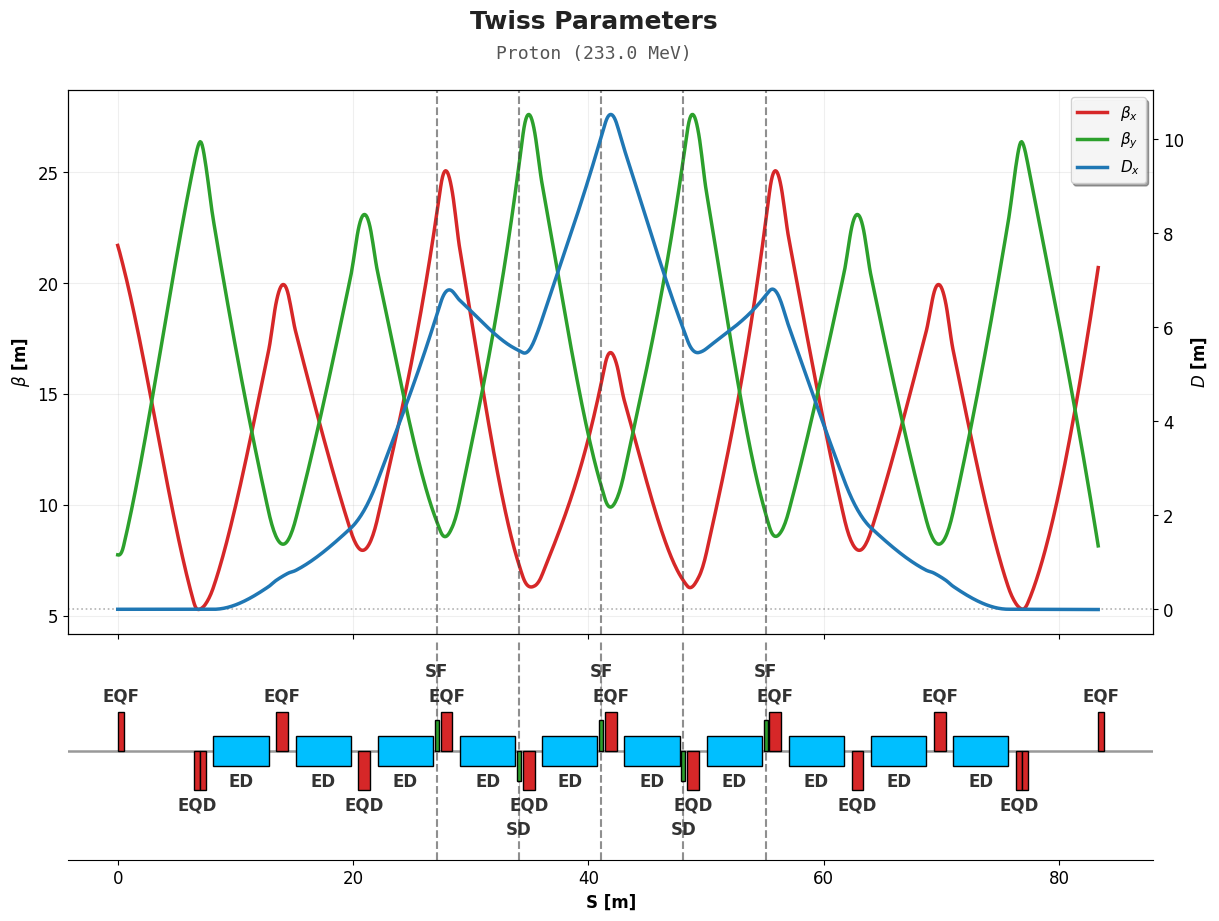

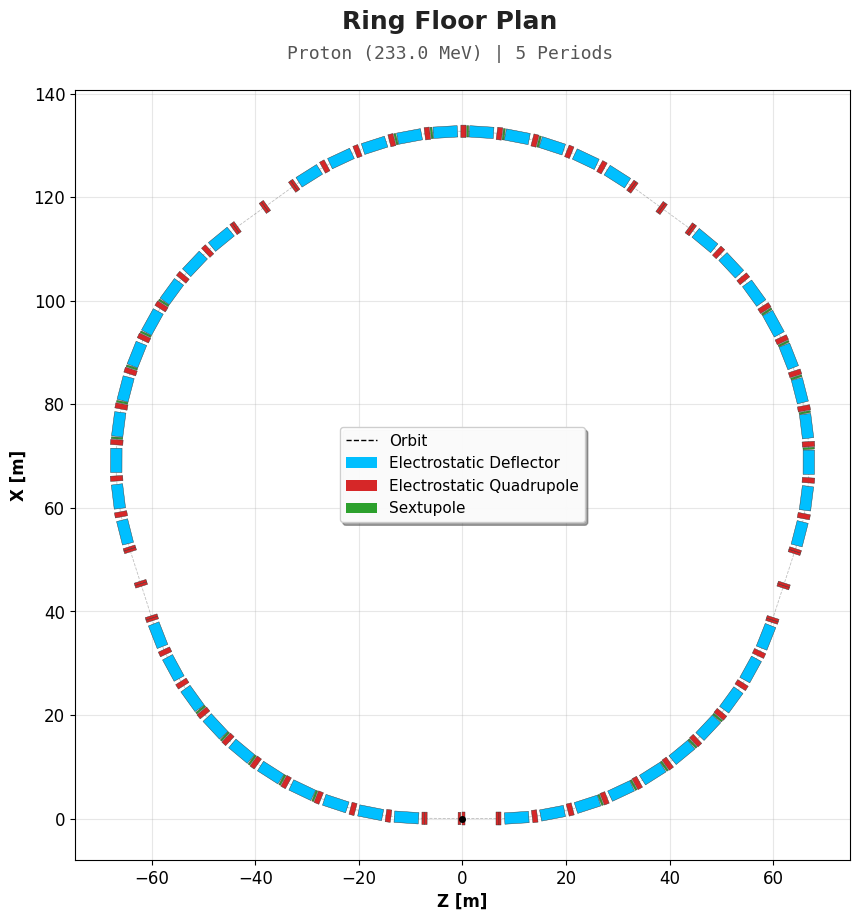

In [367]:
p = Proton(233.0)
# 1. Оптика (Теперь передаем particle для красивого заголовка)
plot_optics(sequence, particle=p, title="Twiss Parameters")

# 2. Floor Plan
plot_floor_plan(sequence, particle=p, n_periods=5, title="Ring Floor Plan")
